<a href="https://colab.research.google.com/github/muhammadhasbiashiddiqi/PCVK_Genap_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mengubah tingkat kecerahan citra
-----------------------------------
Masukkan nilai kecerahan: 30
✅ Gambar berhasil dimuat: (1080, 1080, 3)


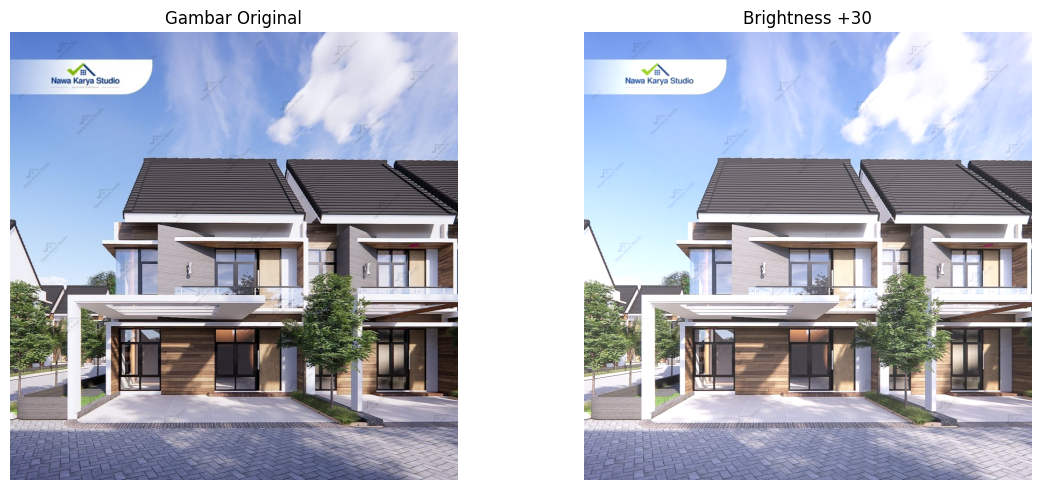

✅ Gambar disimpan ke: /content/drive/MyDrive/PCVK/Gambar/houses.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

print('Mengubah tingkat kecerahan citra')
print('-' * 35)

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    exit()


image_path = '/content/drive/MyDrive/PCVK/Gambar/houses.jpg'

if not Path(image_path).exists():
    print(f"❌ File tidak ditemukan: {image_path}")
    print("Periksa nama folder dan file Anda!")
    exit()

original = cv2.imread(image_path)


brightness_image = cv2.convertScaleAbs(original, beta=brightness)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gambar Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(brightness_image, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Brightness +{brightness}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

output_path = '/content/drive/MyDrive/PCVK/Gambar/houses.jpg'
cv2.imwrite(output_path, brightness_image)
print(f"✅ Gambar disimpan ke: {output_path}")

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from pathlib import Path
try:
    drive.mount('/content/drive', force_remount=False)

except:
    drive.mount('/content/drive', force_remount=True)
image_path = '/content/drive/MyDrive/PCVK/Gambar/houses.jpg'
original = cv2.imread(image_path)
if original is None:
    exit()
inverted_image = 255 - original
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gambar Original', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Inverse
axes[1].imshow(cv2.cvtColor(inverted_image, cv2.COLOR_BGR2RGB))
axes[1].set_title('Inverse Citra (255 - Pixel)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()
output_path = '/content/drive/MyDrive/PCVK_Gambar/houses_inverse.jpg'
success = cv2.imwrite(output_path, inverted_image)
print("="*50)

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow   # tambahkan baris ini

try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/sunset.jpg')
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            contrast_image[y, x, c] = np.clip(
                contrast * original[y, x, c] + brightness, 0, 255
            )

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

In [ ]:
import cv2 as cv
import numpy as np
import math
from google.colab.patches import cv2_imshow
try:
    c = float(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/sunset.jpg')
log_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for ch in range(original.shape[2]):
            pixel = float(original[y, x, ch])          # <-- cast ke float
            log_image[y, x, ch] = np.clip(
                c * math.log(1 + pixel), 0, 255
            )

final_frame = cv.hconcat((original, log_image))
cv2_imshow(final_frame)

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/pappers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

gray_avg = np.zeros((original.shape[0], original.shape[1]), dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        gray_avg[y, x] = np.clip((int(r) + int(g) + int(b)) / 3, 0, 255)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original_rgb)
axs[0].set_title('Citra Asli')
axs[1].imshow(gray_avg, cmap='gray')
axs[1].set_title('Grayscale - Averaging')
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/pappers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
gray_lightness = np.zeros((original.shape[0], original.shape[1]), dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        max_val = max(r, g, b)
        min_val = min(r, g, b)
        gray_lightness[y, x] = np.clip((int(max_val) + int(min_val)) / 2, 0, 255)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original_rgb)
axs[0].set_title('Citra Asli')
axs[1].imshow(gray_lightness, cmap='gray')
axs[1].set_title('Grayscale - Lightness')
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/pappers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
gray_luminance = np.zeros((original.shape[0], original.shape[1]), dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        gray_luminance[y, x] = np.clip(0.21 * int(r) + 0.72 * int(g) + 0.07 * int(b), 0, 255)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original_rgb)
axs[0].set_title('Citra Asli')
axs[1].imshow(gray_luminance, cmap='gray')
axs[1].set_title('Grayscale - Luminance')
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/pappers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
result = np.zeros(original.shape, original.dtype)
threshold = 20

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        r, g, b = int(r), int(g), int(b)
        if r > g + threshold and r > b + threshold:
            result[y, x] = original[y, x]
        else:
            gray = np.clip(0.21 * r + 0.72 * g + 0.07 * b, 0, 255)
            result[y, x] = [gray, gray, gray]

result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original_rgb)
axs[0].set_title('Citra Asli')
axs[1].imshow(result_rgb)
axs[1].set_title('Warna Merah Dipertahankan, Lainnya Grayscale')
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/sunset.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

gamma_image = np.zeros(original.shape, original.dtype)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            I = float(original[y, x, c])
            gamma_image[y, x, c] = np.clip(
                255 * ((I / 255) ** (1 / gamma)), 0, 255
            )

gamma_image_rgb = cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original_rgb)
axs[0].set_title('Citra Asli')
axs[1].imshow(gamma_image_rgb)
axs[1].set_title(f'Gamma Correction (γ = {gamma})')
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
    if bit_depth < 1 or bit_depth > 8:
        raise ValueError('Bit depth harus antara 1-8')
except ValueError as e:
    print('Error:', e)

level = 255 / (pow(2, bit_depth) - 1)

# baca citra dalam grayscale
original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/pappers.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

# akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        C = original[y, x]
        depth_image[y, x] = np.clip(round((C / level) * level), 0, 255)

print(f'Bit depth awal : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level    : {bit_depth}')

# tampilkan citra asli dan hasil kuantisasi
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original, cmap='gray')
axs[0].set_title('Grayscale 8-bit')
axs[1].imshow(depth_image, cmap='gray')
axs[1].set_title(f'Grayscale {bit_depth}-bit')
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import glob
import matplotlib.pyplot as plt
from math import log10, sqrt
def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr
original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/galaxy.jpg')
cv_img = []
target_h, target_w = original.shape[:2]

for img in sorted(glob.glob('/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/noises/*.jpg')):
    n = cv.imread(img)
    if n is None:
        print(f"WARNING: gagal membaca {img}, dilewati")
        continue
    if n.shape[:2] != (target_h, target_w):
        n = cv.resize(n, (target_w, target_h))
    cv_img.append(n)

print(f"Jumlah citra noise yang terbaca: {len(cv_img)}")
if len(cv_img) == 0:
    raise ValueError("Tidak ada citra noise yang terbaca. Cek kembali path folder 'noises'.")
def average_denoising(images, n):
    subset = images[:n]
    acc = np.zeros(subset[0].shape, dtype=np.float64)

    for img in subset:
        acc += img.astype(np.float64)

    avg = acc / n
    avg = np.clip(np.round(avg), 0, 255).astype(np.uint8)
    return avg
jumlah_citra_list = [10, 20, 40, 80, 100]
hasil_denoise = []
hasil_psnr = []

for n in jumlah_citra_list:
    denoised = average_denoising(cv_img, n)
    psnr_value = PSNR(original, denoised)

    hasil_denoise.append(denoised)
    hasil_psnr.append(psnr_value)

    print(f"Jumlah citra di-average: {n:3d}  ->  PSNR: {psnr_value:.2f} dB")
fig, axes = plt.subplots(1, len(jumlah_citra_list) + 1, figsize=(20, 4))
axes[0].imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis('off')
for i, n in enumerate(jumlah_citra_list):
    axes[i + 1].imshow(cv.cvtColor(hasil_denoise[i], cv.COLOR_BGR2RGB))
    axes[i + 1].set_title(f"Average {n} citra\nPSNR: {hasil_psnr[i]:.2f} dB")
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()
for n, img in zip(jumlah_citra_list, hasil_denoise):
    cv.imwrite(f'/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/hasil_avg_{n}.jpg', img)

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/couple.jpg')
h, w = original.shape[:2]
maskA = np.zeros((h, w), dtype=np.uint8)
maskB = np.zeros((h, w), dtype=np.uint8)
centerA = (int(w * 0.30), int(h * 0.35))
radiusA = int(min(h, w) * 0.15)
cv.circle(maskA, centerA, radiusA, 255, -1)
centerB = (int(w * 0.60), int(h * 0.35))
radiusB = int(min(h, w) * 0.15)
cv.circle(maskB, centerB, radiusB, 255, -1)
def apply_mask(image, mask):
    return cv.bitwise_and(image, image, mask=mask)
mask_not      = cv.bitwise_not(maskA)
mask_or       = cv.bitwise_or(maskA, maskB)
mask_and      = cv.bitwise_and(maskA, maskB)
mask_nand     = cv.bitwise_not(cv.bitwise_and(maskA, maskB))
mask_xor      = cv.bitwise_xor(maskA, maskB)
result_not  = apply_mask(original, mask_not)
result_or   = apply_mask(original, mask_or)
result_and  = apply_mask(original, mask_and)
result_nand = apply_mask(original, mask_nand)
result_xor  = apply_mask(original, mask_xor)
def to_rgb(img):
    return cv.cvtColor(img, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

axes[0, 0].imshow(to_rgb(original)); axes[0, 0].set_title("Original"); axes[0, 0].axis('off')
axes[0, 1].imshow(maskA, cmap='gray'); axes[0, 1].set_title("Mask A"); axes[0, 1].axis('off')
axes[0, 2].imshow(maskB, cmap='gray'); axes[0, 2].set_title("Mask B"); axes[0, 2].axis('off')
axes[0, 3].axis('off')  # kosong

axes[1, 0].imshow(to_rgb(result_not));  axes[1, 0].set_title("NOT(A)");      axes[1, 0].axis('off')
axes[1, 1].imshow(to_rgb(result_or));   axes[1, 1].set_title("A OR B");      axes[1, 1].axis('off')
axes[1, 2].imshow(to_rgb(result_and));  axes[1, 2].set_title("A AND B");     axes[1, 2].axis('off')
axes[1, 3].imshow(to_rgb(result_xor));  axes[1, 3].set_title("A XOR B");     axes[1, 3].axis('off')

plt.tight_layout()
plt.show()
plt.figure(figsize=(4, 4))
plt.imshow(to_rgb(result_nand))
plt.title("A NAND B")
plt.axis('off')
plt.show()
output_dir = '/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/'
cv.imwrite(output_dir + 'masking_not.jpg',  result_not)
cv.imwrite(output_dir + 'masking_or.jpg',   result_or)
cv.imwrite(output_dir + 'masking_and.jpg',  result_and)
cv.imwrite(output_dir + 'masking_nand.jpg', result_nand)
cv.imwrite(output_dir + 'masking_xor.jpg',  result_xor)

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/Malam_hari.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

def linear_brightness(img, b):
    return np.clip(img.astype(np.float64) + b, 0, 255).astype(np.uint8)

def contrast(img, c, b=0):
    factor = (259 * (c + 255)) / (255 * (259 - c))
    result = factor * (img.astype(np.float64) - 128) + 128 + b
    return np.clip(result, 0, 255).astype(np.uint8)

def log_brightness(img, c=None):
    img_f = img.astype(np.float64)
    if c is None:
        c = 255 / np.log(1 + 255)
    result = c * np.log(1 + img_f)
    return np.clip(result, 0, 255).astype(np.uint8)

def gamma_correction(img, gamma):
    img_f = img.astype(np.float64) / 255.0
    result = 255 * (img_f ** (1.0 / gamma))
    return np.clip(result, 0, 255).astype(np.uint8)
hasil_linear  = linear_brightness(original, b=60)
hasil_contrast = contrast(original, c=-40, b=40)
hasil_log     = log_brightness(original)
hasil_gamma   = gamma_correction(original, gamma=2.5)

def to_rgb(img):
    return cv.cvtColor(img, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

axes[0].imshow(original_rgb); axes[0].set_title("Original (gelap)"); axes[0].axis('off')
axes[1].imshow(to_rgb(hasil_linear));   axes[1].set_title("Linear Brightness (b=60)"); axes[1].axis('off')
axes[2].imshow(to_rgb(hasil_contrast)); axes[2].set_title("Contrast (c=-40, b=40)"); axes[2].axis('off')
axes[3].imshow(to_rgb(hasil_log));      axes[3].set_title("Log Brightness"); axes[3].axis('off')
axes[4].imshow(to_rgb(hasil_gamma));    axes[4].set_title("Gamma Correction (γ=2.5)"); axes[4].axis('off')

plt.tight_layout()
plt.show()
cv.imwrite('/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/malam_hari_hasil.jpg', hasil_gamma)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_rgb); axes[0].set_title("Before"); axes[0].axis('off')
axes[1].imshow(to_rgb(hasil_gamma)); axes[1].set_title("After (Gamma Correction, γ=2.5)"); axes[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/crayfish.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
def linear_brightness(img, b):
    return np.clip(img.astype(np.float64) + b, 0, 255).astype(np.uint8)

def contrast(img, c, b=0):
    factor = (259 * (c + 255)) / (255 * (259 - c))
    result = factor * (img.astype(np.float64) - 128) + 128 + b
    return np.clip(result, 0, 255).astype(np.uint8)

def gamma_correction(img, gamma):
    img_f = img.astype(np.float64) / 255.0
    result = 255 * (img_f ** (1.0 / gamma))
    return np.clip(result, 0, 255).astype(np.uint8)
step1_contrast = contrast(original, c=60, b=0)
step2_gamma = gamma_correction(step1_contrast, gamma=1.4)

hasil_akhir = step2_gamma
kombinasi = [
    ("Contrast c=40",              contrast(original, c=40)),
    ("Contrast c=60",              contrast(original, c=60)),
    ("Contrast c=60 + Gamma 1.2",  gamma_correction(contrast(original, c=60), 1.2)),
    ("Contrast c=60 + Gamma 1.4",  gamma_correction(contrast(original, c=60), 1.4)),
    ("Contrast c=60 + Gamma 1.6",  gamma_correction(contrast(original, c=60), 1.6)),
]

fig, axes = plt.subplots(1, len(kombinasi) + 1, figsize=(24, 5))
axes[0].imshow(original_rgb); axes[0].set_title("Original"); axes[0].axis('off')

for i, (label, img) in enumerate(kombinasi):
    axes[i + 1].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axes[i + 1].set_title(label, fontsize=9)
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_rgb); axes[0].set_title("Before"); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(hasil_akhir, cv.COLOR_BGR2RGB))
axes[1].set_title("After (Contrast c=60 + Gamma γ=1.4)")
axes[1].axis('off')
plt.tight_layout()
plt.show()
cv.imwrite('/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/crayfish_hasil.jpg', hasil_akhir)